<a href="https://colab.research.google.com/github/Sivanunna/Logicmojo-AI-ML-Sept25--siva-/blob/main/Kmeans_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [77]:
import numpy as np
import pandas as pd
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [78]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Country-data.csv')
df

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [79]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


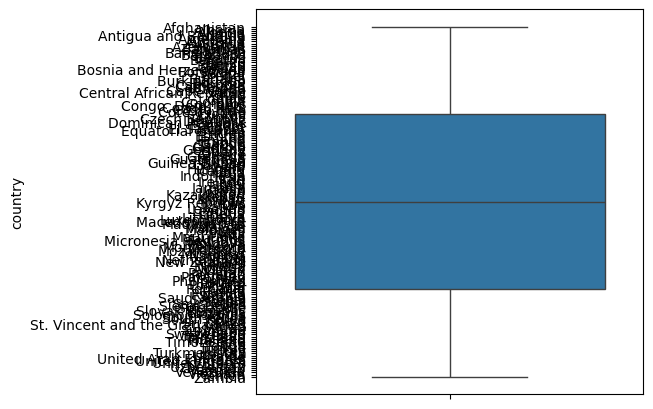

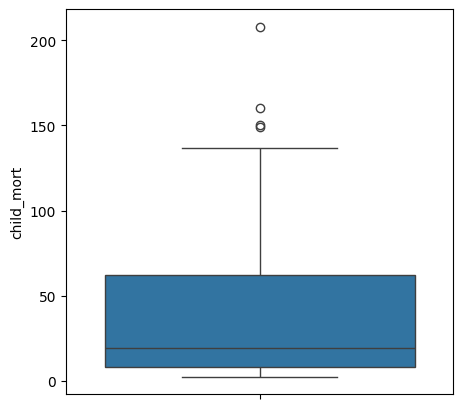

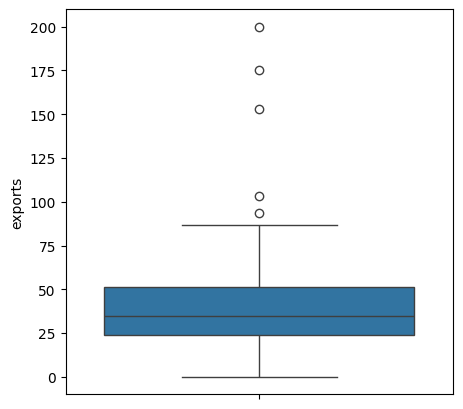

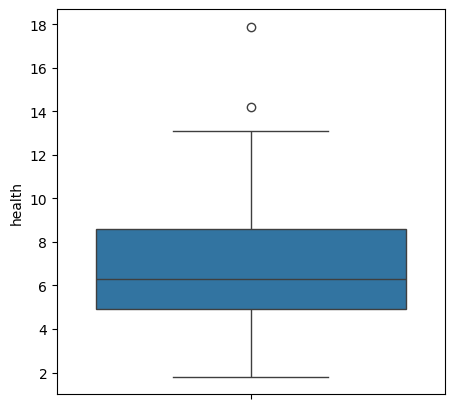

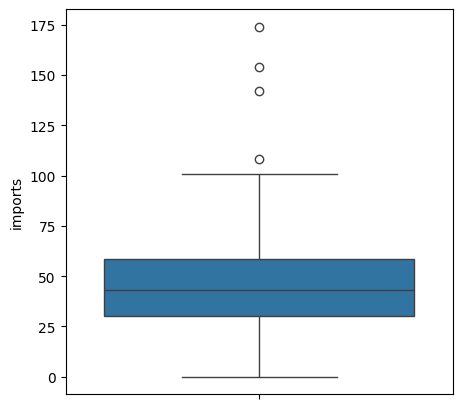

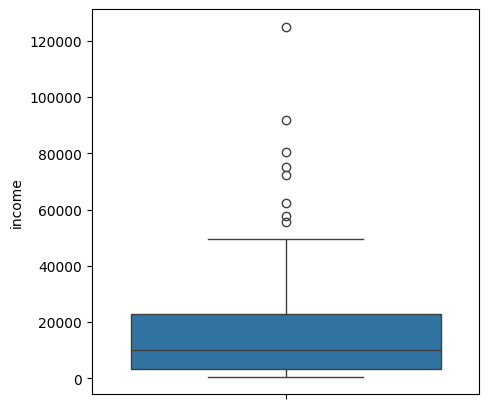

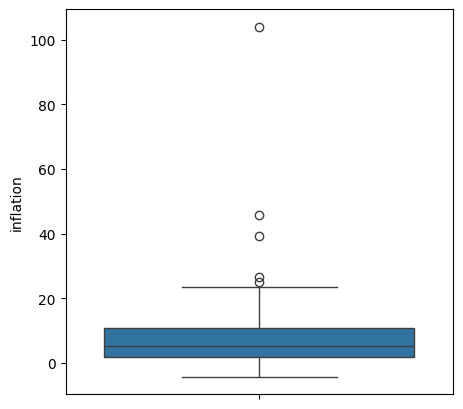

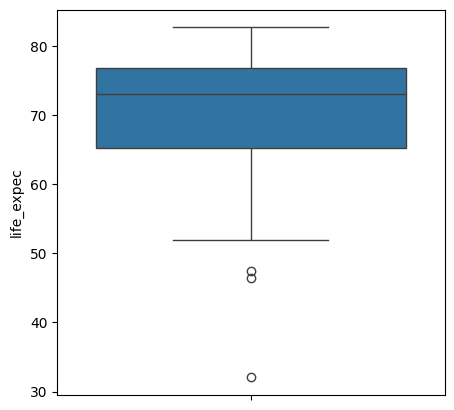

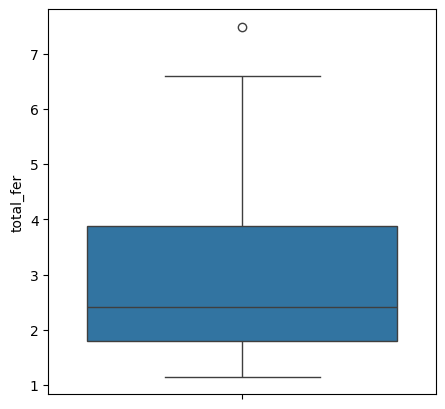

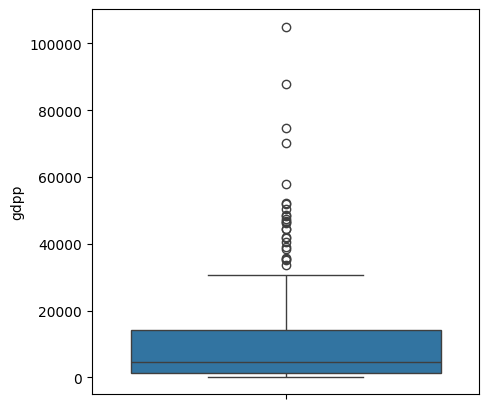

In [80]:
for col in df:
  plt.figure(figsize=(5,5))
  sns.boxplot(df[col])
  plt.show()

<Axes: ylabel='gdpp'>

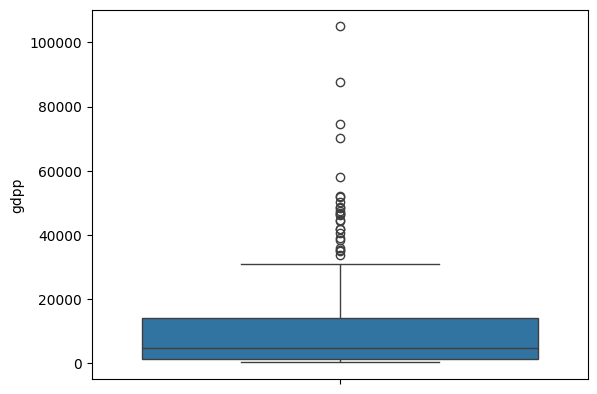

In [81]:
sns.boxplot(df['gdpp'])

In [82]:
Q1 = df.gdpp.quantile(0.25)
Q3 = df.gdpp.quantile(0.75)
IQR = Q3-Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df['gdpp'] =  df['gdpp'].clip(lower, upper)


In [83]:
Q1 = df.income.quantile(0.25)
Q3 = df.income.quantile(0.75)
IQR = Q3-Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df['income'] =  df['income'].clip(lower, upper)


In [85]:
Q1 = df.life_expec.quantile(0.25)
Q3 = df.life_expec.quantile(0.75)
IQR = Q3-Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df['life_expec'] =  df['life_expec'].clip(lower, upper)

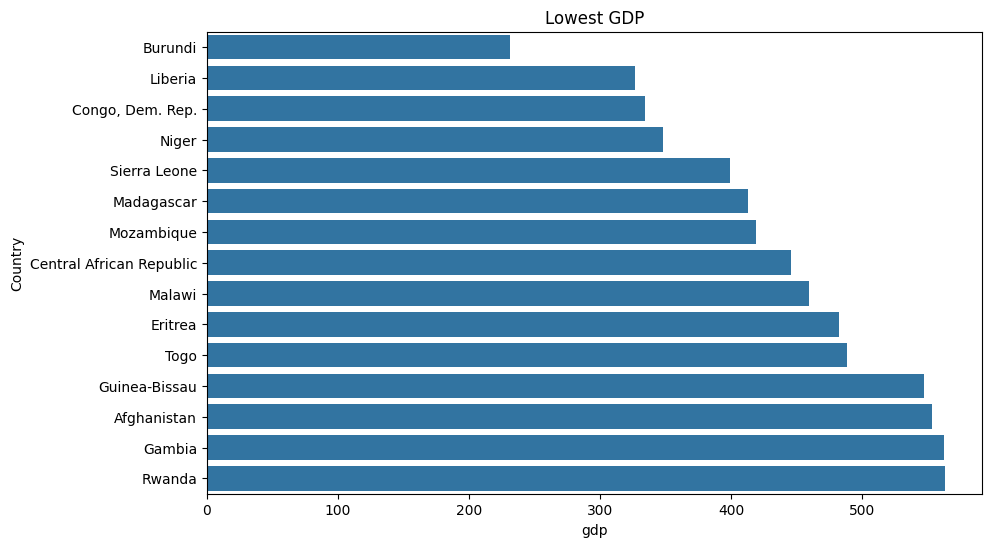

In [88]:
lowest_gdp = df.sort_values(by='gdpp', ascending=True).head(15)
lowest_gdp
plt.figure(figsize=(10,6))
sns.barplot(y='country', x='gdpp', data=lowest_gdp)

plt.title("Lowest GDP")
plt.xlabel("gdp")
plt.ylabel("Country")

plt.show()

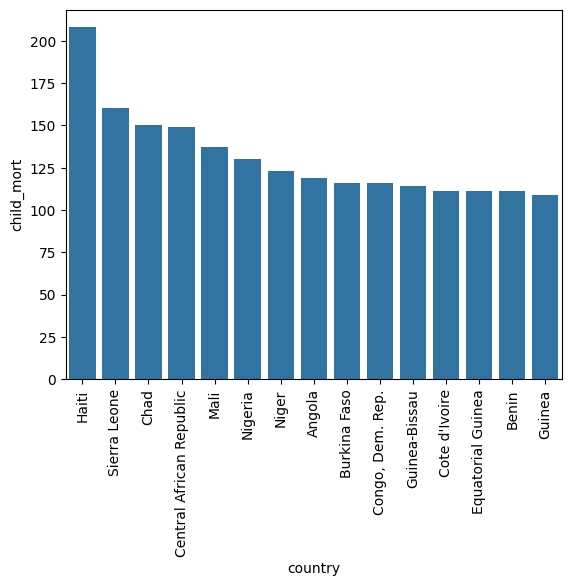

In [89]:
Highest_deathrates = df.sort_values(by='child_mort',ascending=False).head(15)
sns.barplot(x='country',y='child_mort',data=Highest_deathrates)
plt.xticks(rotation=90)
plt.show()

In [90]:
numcol = df.select_dtypes(include='number')
numcol

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610.0,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930.0,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900.0,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900.0,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100.0,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...
162,29.2,46.6,5.25,52.7,2950.0,2.62,63.0,3.50,2970
163,17.1,28.5,4.91,17.6,16500.0,45.90,75.4,2.47,13500
164,23.3,72.0,6.84,80.2,4490.0,12.10,73.1,1.95,1310
165,56.3,30.0,5.18,34.4,4480.0,23.60,67.5,4.67,1310


In [91]:
categorialcol = df['country']
categorialcol

,country
0,Afghanistan
1,Albania
2,Algeria
3,Angola
4,Antigua and Barbuda
...,...
162,Vanuatu
163,Venezuela
164,Vietnam
165,Yemen


In [92]:
numcol.columns

Index(['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

In [95]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

numcols = numcol.columns
numindex = numcol.index

numcol = scaler.fit_transform(numcol)

numcol = pd.DataFrame(numcol, columns=numcols, index=numindex)

numcol

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,0.426485,0.049482,0.358608,0.257765,0.019490,0.126144,0.234532,0.736593,0.009788
1,0.068160,0.139531,0.294593,0.279037,0.181489,0.080399,0.812950,0.078864,0.117298
2,0.120253,0.191559,0.146675,0.180149,0.239318,0.187691,0.818705,0.274448,0.128545
3,0.566699,0.311125,0.064636,0.246266,0.103021,0.245911,0.346763,0.790221,0.100277
4,0.037488,0.227079,0.262275,0.338255,0.360038,0.052213,0.827338,0.154574,0.363810
...,...,...,...,...,...,...,...,...,...
162,0.129503,0.232582,0.213797,0.302609,0.045582,0.063118,0.430216,0.370662,0.083255
163,0.070594,0.142032,0.192666,0.100809,0.309413,0.463081,0.787050,0.208202,0.403325
164,0.100779,0.359651,0.312617,0.460715,0.075567,0.150725,0.720863,0.126183,0.032797
165,0.261441,0.149536,0.209447,0.197397,0.075372,0.257000,0.559712,0.555205,0.032797


In [96]:
from sklearn.neighbors import NearestNeighbors
from random import sample
from numpy.random import uniform
import numpy as np
from math import isnan

def hopkins(X):
    d = X.shape[1]
    #d = len(vars) # columns
    n = len(X) # rows
    m = int(0.1 * n)
    nbrs = NearestNeighbors(n_neighbors=1).fit(X.values)

    rand_X = sample(range(0, n, 1), m)

    ujd = []
    wjd = []
    for j in range(0, m):
        u_dist, _ = nbrs.kneighbors(uniform(np.amin(X,axis=0),np.amax(X,axis=0),d).reshape(1, -1), 2, return_distance=True)
        ujd.append(u_dist[0][1])
        w_dist, _ = nbrs.kneighbors(X.iloc[rand_X[j]].values.reshape(1, -1), 2, return_distance=True)
        wjd.append(w_dist[0][1])

    H = sum(ujd) / (sum(ujd) + sum(wjd))
    if isnan(H):
        print(ujd, wjd)
        H = 0

    return H

In [97]:
hopkins(numcol)

np.float64(0.8549122957118074)

In [98]:
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import cut_tree

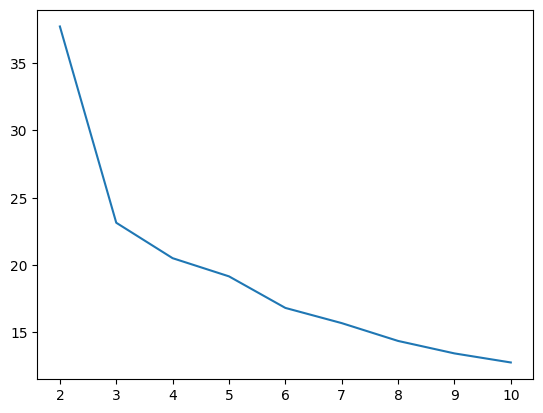

In [99]:
ssd = []
for k in range(2,11):
    kmean = KMeans(n_clusters = k).fit(numcol)
    ssd.append([k, kmean.inertia_])

ssd = pd.DataFrame(ssd)
plt.plot(ssd[0], ssd[1])

In [101]:

range_n_clusters = [2, 3, 4, 5, 6, 7, 8]

for num_clusters in range_n_clusters:

    # intialise kmeans
    kmeans = KMeans(n_clusters=num_clusters, max_iter=50)
    kmeans.fit(numcol)

    cluster_labels = kmeans.labels_

    # silhouette score
    silhouette_avg = silhouette_score(numcol, cluster_labels)
    print("For n_clusters={0}, the silhouette score is {1}".format(num_clusters, silhouette_avg))

For n_clusters=2, the silhouette score is 0.4774621826011351
For n_clusters=3, the silhouette score is 0.41692556593523344
For n_clusters=4, the silhouette score is 0.28616636420958574
For n_clusters=5, the silhouette score is 0.2798776448409919
For n_clusters=6, the silhouette score is 0.23636151834039607
For n_clusters=7, the silhouette score is 0.22940694757290145
For n_clusters=8, the silhouette score is 0.22251758385265474


In [102]:
kmeans = KMeans(n_clusters=4, max_iter=50, random_state = 0)
kmeans.fit(numcol)

KMeans(max_iter=50, n_clusters=4, random_state=0)

In [103]:
df['clusterid'] = kmeans.labels_
df

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,clusterid
0,Afghanistan,90.2,10.0,7.58,44.9,1610.0,9.44,56.2,5.82,553,2
1,Albania,16.6,28.0,6.55,48.6,9930.0,4.49,76.3,1.65,4090,1
2,Algeria,27.3,38.4,4.17,31.4,12900.0,16.10,76.5,2.89,4460,1
3,Angola,119.0,62.3,2.85,42.9,5900.0,22.40,60.1,6.16,3530,2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100.0,1.44,76.8,2.13,12200,1
...,...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950.0,2.62,63.0,3.50,2970,2
163,Venezuela,17.1,28.5,4.91,17.6,16500.0,45.90,75.4,2.47,13500,1
164,Vietnam,23.3,72.0,6.84,80.2,4490.0,12.10,73.1,1.95,1310,1
165,Yemen,56.3,30.0,5.18,34.4,4480.0,23.60,67.5,4.67,1310,2


In [104]:
df.clusterid.value_counts()

,count
clusterid,
1,79
2,50
3,35
0,3


<Axes: xlabel='gdpp', ylabel='child_mort'>

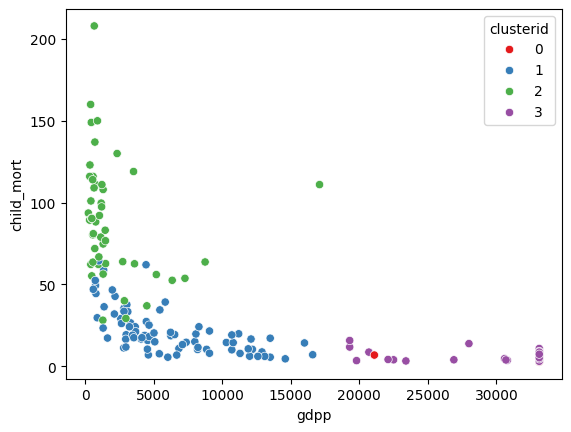

In [106]:
sns.scatterplot(x = 'gdpp', y ='child_mort', hue = 'clusterid', data = df, palette = 'Set1')

<Axes: xlabel='gdpp', ylabel='income'>

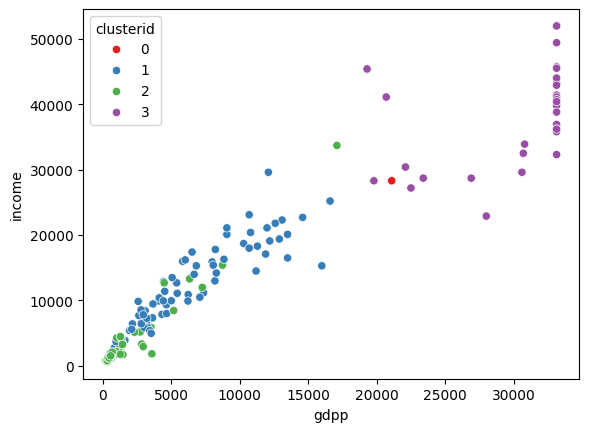

In [108]:
sns.scatterplot(x = 'gdpp', y ='income', hue = 'clusterid', data = df, palette = 'Set1')

<Axes: xlabel='income', ylabel='child_mort'>

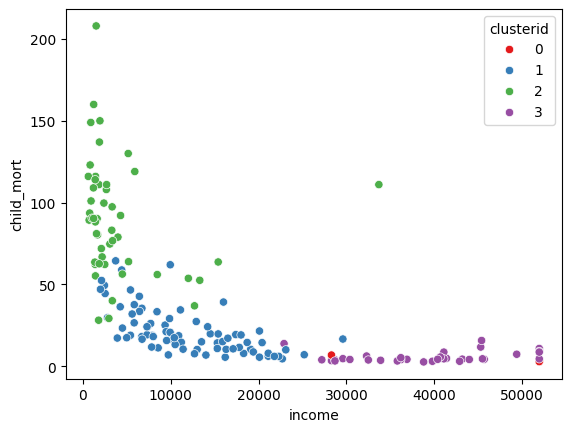

In [109]:
sns.scatterplot(x = 'income', y ='child_mort', hue = 'clusterid', data = df, palette = 'Set1')

<Axes: xlabel='clusterid', ylabel='child_mort'>

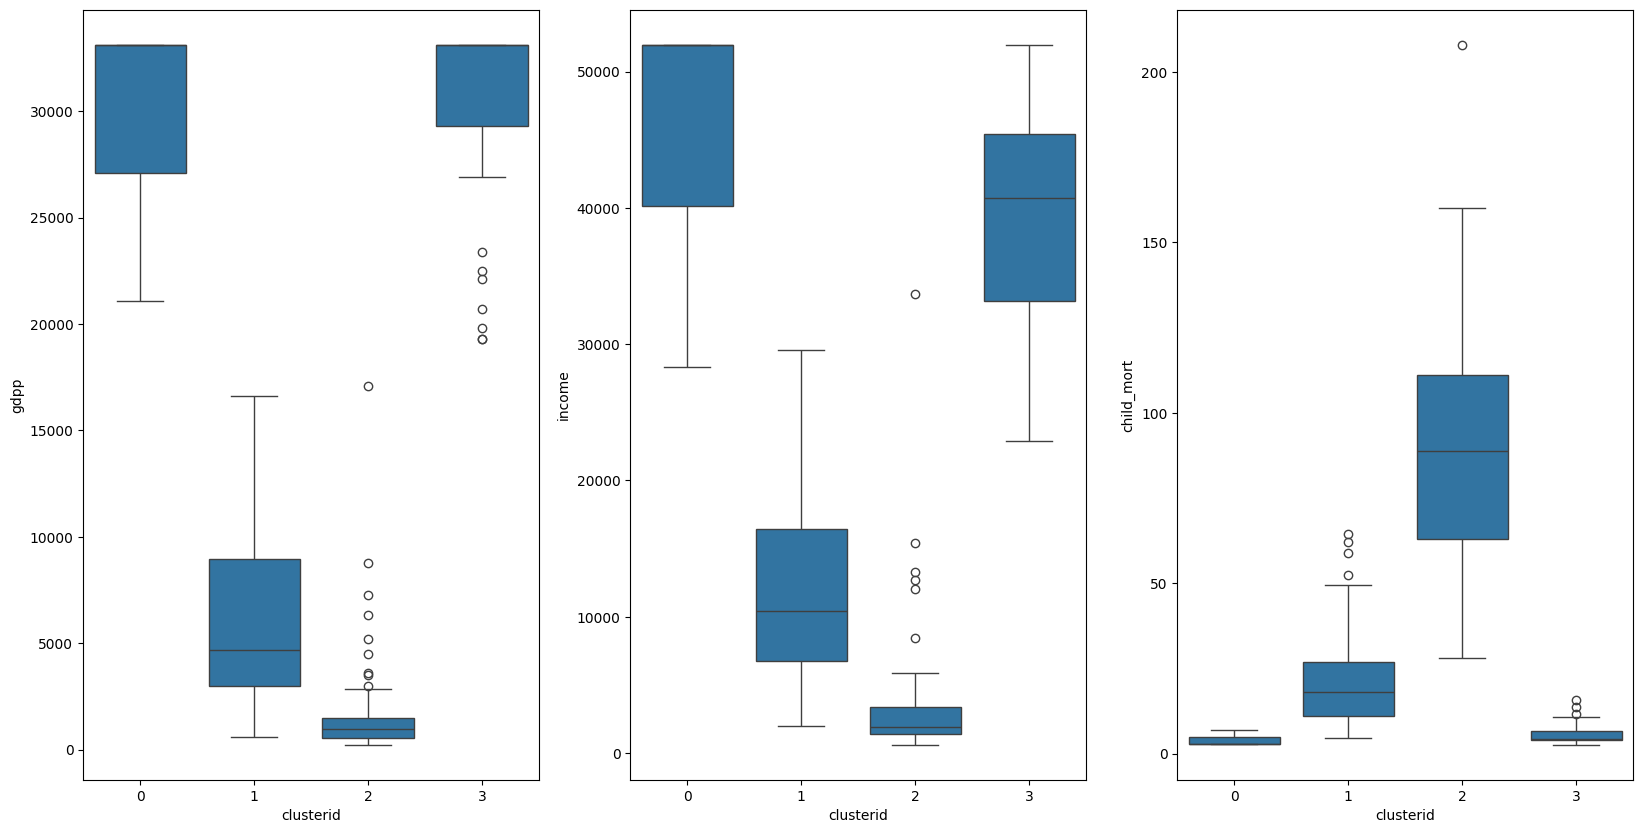

In [114]:
plt.figure(figsize = (20,10))
plt.subplot(1,3,1)
sns.boxplot(x='clusterid', y='gdpp', data= df)




plt.subplot(1,3,2)
sns.boxplot(x='clusterid', y='income', data= df)



plt.subplot(1,3,3)
sns.boxplot(x='clusterid', y='child_mort', data= df)

In [116]:
df[['gdpp', 'child_mort', 'income', 'clusterid']].groupby('clusterid').mean()

,gdpp,child_mort,income
clusterid,,,
0,29120.000000,4.133333,44078.333333
1,6173.949367,21.650633,11863.291139
2,1949.440000,89.330000,3867.260000
3,30174.000000,5.765714,39888.714286


In [121]:
kmeans = KMeans(n_clusters=3, max_iter=50, random_state = 0)
kmeans.fit(numcol)

KMeans(max_iter=50, n_clusters=3, random_state=0)

In [122]:
df['cluster_id'] = kmeans.labels_
df

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,clusterid,cluster_id
0,Afghanistan,90.2,10.0,7.58,44.9,1610.0,9.44,56.2,5.82,553,2,2
1,Albania,16.6,28.0,6.55,48.6,9930.0,4.49,76.3,1.65,4090,1,1
2,Algeria,27.3,38.4,4.17,31.4,12900.0,16.10,76.5,2.89,4460,1,1
3,Angola,119.0,62.3,2.85,42.9,5900.0,22.40,60.1,6.16,3530,2,2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100.0,1.44,76.8,2.13,12200,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950.0,2.62,63.0,3.50,2970,2,2
163,Venezuela,17.1,28.5,4.91,17.6,16500.0,45.90,75.4,2.47,13500,1,1
164,Vietnam,23.3,72.0,6.84,80.2,4490.0,12.10,73.1,1.95,1310,1,1
165,Yemen,56.3,30.0,5.18,34.4,4480.0,23.60,67.5,4.67,1310,2,2


In [123]:
df.cluster_id.value_counts()

,count
cluster_id,
1,79
2,50
0,38


In [124]:
mean_df = df[['gdpp', 'child_mort', 'income', 'cluster_id']].groupby('cluster_id').mean()
mean_df

,gdpp,child_mort,income
cluster_id,,,
0,30090.789474,5.636842,40219.473684
1,6173.949367,21.650633,11863.291139
2,1949.440000,89.330000,3867.260000


<Axes: xlabel='cluster_id', ylabel='child_mort'>

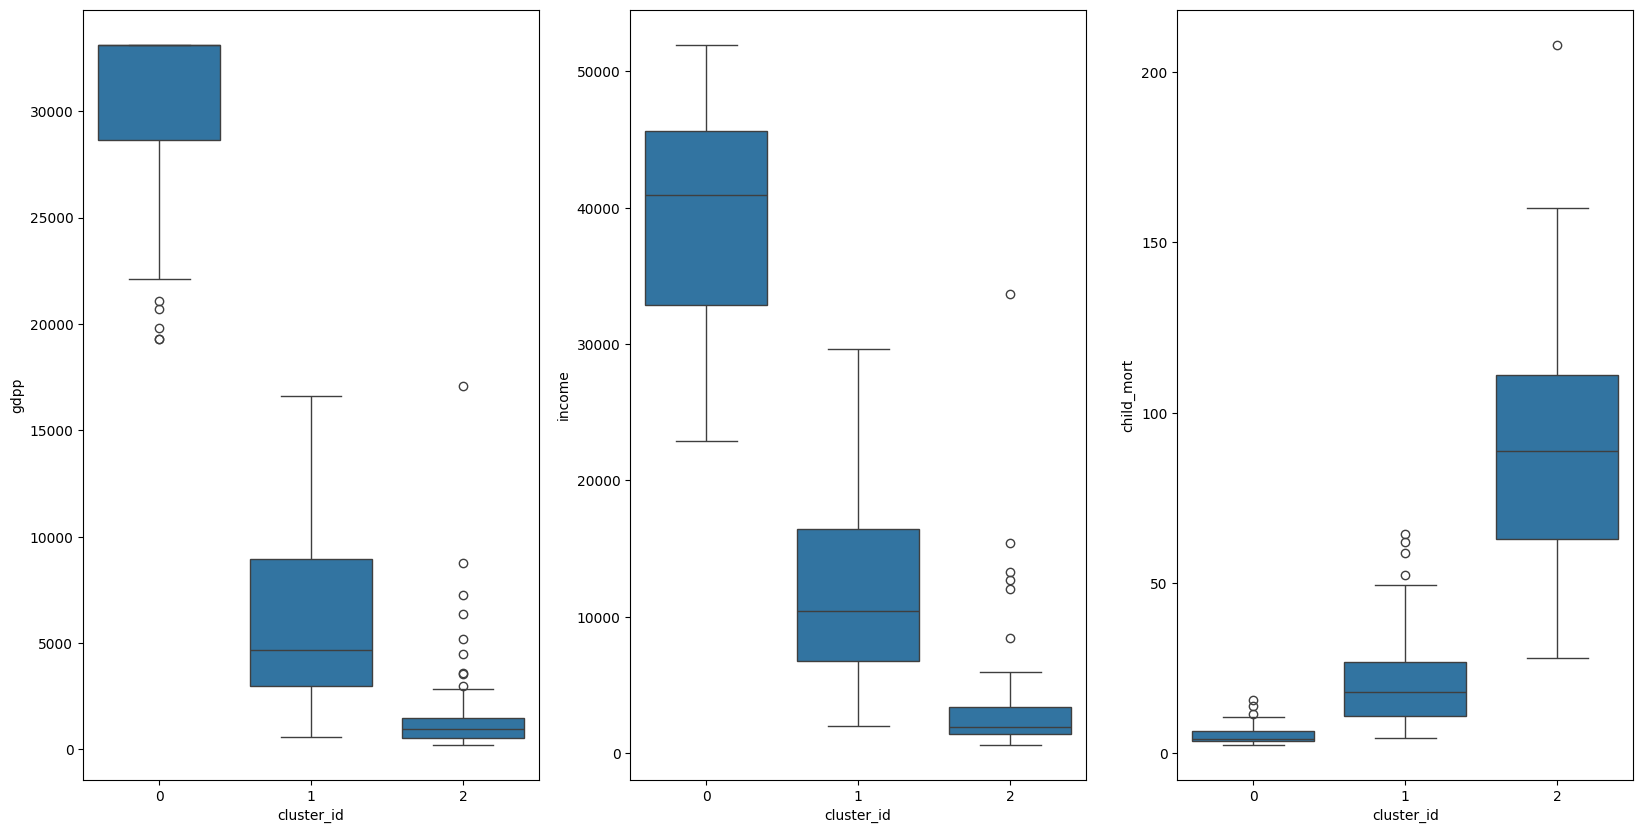

In [128]:
plt.figure(figsize = (20,10))
plt.subplot(1,3,1)
sns.boxplot(x='cluster_id', y='gdpp', data= df)




plt.subplot(1,3,2)
sns.boxplot(x='cluster_id', y='income', data= df)



plt.subplot(1,3,3)
sns.boxplot(x='cluster_id', y='child_mort', data= df)

<Axes: xlabel='income', ylabel='child_mort'>

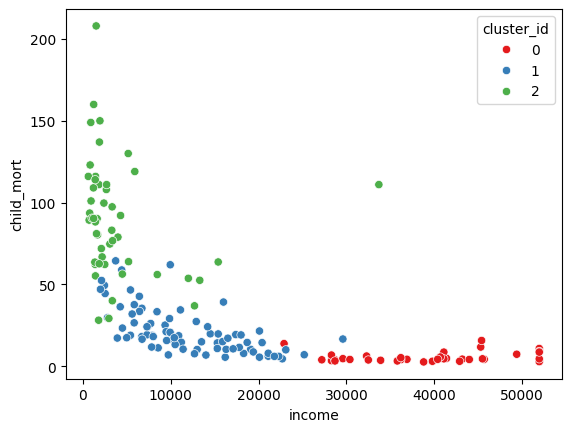

In [129]:
sns.scatterplot(x = 'income', y ='child_mort', hue = 'cluster_id', data = df, palette = 'Set1')

<Axes: xlabel='gdpp', ylabel='child_mort'>

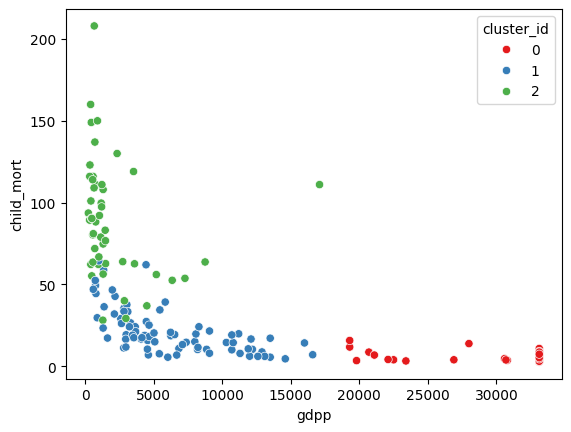

In [130]:
sns.scatterplot(x = 'gdpp', y ='child_mort', hue = 'cluster_id', data = df, palette = 'Set1')

<Axes: xlabel='gdpp', ylabel='income'>

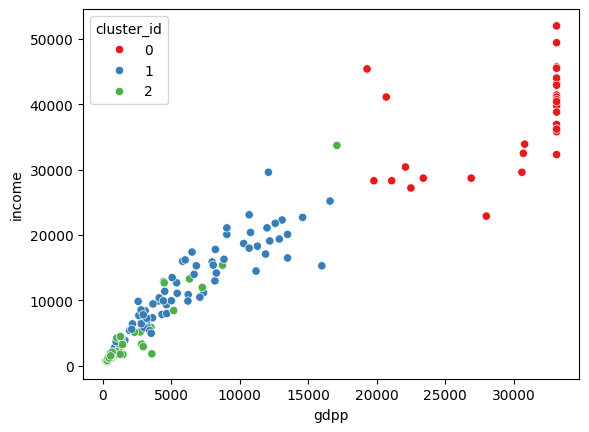

In [131]:
sns.scatterplot(x = 'gdpp', y ='income', hue = 'cluster_id', data = df, palette = 'Set1')

In [127]:
df.sort_values(by = ['gdpp', 'child_mort', 'income'], ascending = [True, False, True]).head(5)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,clusterid,cluster_id
26,Burundi,93.6,8.92,11.60,39.2,764.0,12.30,57.7,6.26,231,2,2
88,Liberia,89.3,19.10,11.80,92.6,700.0,5.47,60.8,5.02,327,2,2
37,"Congo, Dem. Rep.",116.0,41.10,7.91,49.6,609.0,20.80,57.5,6.54,334,2,2
112,Niger,123.0,22.20,5.16,49.1,814.0,2.55,58.8,7.49,348,2,2
132,Sierra Leone,160.0,16.80,13.10,34.5,1220.0,17.20,55.0,5.20,399,2,2
